# Accelerations — Daily Load Prediction

**Target:** `accelerations` (daily sum, count)

End-to-end pipeline for predicting a player's **accelerations** on a given training day. This is a **cross-sectional regression** — each player-day row is an independent observation with no lag or EWMA features.

The shared `datapipeline.run_pipeline()` module handles all preprocessing so this notebook focuses purely on model training, evaluation, and interpretation.

## 1. Imports & Setup

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from scipy.stats import loguniform, randint, uniform
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, RandomizedSearchCV, learning_curve
from xgboost import XGBRegressor

from datapipeline import prepare_test, run_pipeline

warnings.filterwarnings("ignore")

TARGET      = "accelerations"
REPO_ROOT   = Path().resolve()
MODEL_DIR   = REPO_ROOT / "models" / "notebook_experiments" / TARGET
MODEL_DIR.mkdir(parents=True, exist_ok=True)


## 2. Data Preprocessing Pipeline

`run_pipeline("accelerations")` chains the following steps:

| Step | Description |
|---|---|
| **Load** | Read raw GPS/IMU CSV (extract from zip if needed) |
| **Clean** | Rename GPS columns, parse dates, compute age, drop rows with missing metadata |
| **Outlier cap** | IQR cap (Q3 + 3×IQR) per player per exercise type on `total_distance` and the target |
| **Aggregate** | Sum periods to player-day; add `has_*` exercise-type one-hot flags |
| **Spine fill** | Insert rest-day zero rows so each player has a contiguous date range |
| **Split** | Random 80/20 row-level split — test set held out until Section 6 |
| **Feature eng.** | Add `day_of_week` → one-hot `dow_0 … dow_6` |
| **Transform** | `log1p(accelerations)`; drop `total_distance` (same-session leakage); MinMaxScale features |

In [2]:
pipeline     = run_pipeline(TARGET)
X_tr_np      = pipeline["X_tr_np"]
y_tr_np      = pipeline["y_tr_np"]
train_base   = pipeline["train_base"]
test_base    = pipeline["test_base"]
scaler       = pipeline["scaler"]
feature_cols = pipeline["feature_cols"]
daily        = pipeline["daily"]

print(f"Feature columns ({len(feature_cols)}): {feature_cols}")


Raw shape: (3903, 13)  (35 players)
Age range: 17–56  |  null ages: 19
Dropping 19 rows from 1 player(s) with missing metadata
Clean period-level shape: (3884, 14)
IQR cap total_distance: 125,666 units reduced
IQR cap accelerations: 118 units reduced
  Trialist 42978: 21 rows  2024-07-27 → 2024-08-07
  Trialist 93116: 16 rows  2024-07-29 → 2024-08-04
  Trialist 86086: 10 rows  2024-07-27 → 2024-08-01
  Trialist 15795: 30 rows  2024-07-30 → 2025-06-26
  Trialist 60819: 2 rows  2025-06-18 → 2025-06-22
  Trialist 89091: 3 rows  2025-06-18 → 2025-06-26
Dropped 82 trialist rows across 6 players
Final period-level dataset: (3802, 14)
Daily shape: (2103, 15)


Building date spine: 100%|██████████| 28/28 [00:00<00:00, 4940.08it/s]

Daily shape after spine fill: (6310, 15)  |  nulls: 0
Train rows: 5048  |  Test rows (held out): 1262
Train shape after feature engineering: (5048, 22)
17 features: ['n_periods', 'n_exercise_types', 'height', 'weight', 'age', 'has_BP', 'has_G', 'has_MATCH', 'has_TAC', 'has_TEC', 'dow_0', 'dow_1', 'dow_2', 'dow_3', 'dow_4', 'dow_5', 'dow_6']
Train null count: 0
Feature columns (17): ['n_periods', 'n_exercise_types', 'height', 'weight', 'age', 'has_BP', 'has_G', 'has_MATCH', 'has_TAC', 'has_TEC', 'dow_0', 'dow_1', 'dow_2', 'dow_3', 'dow_4', 'dow_5', 'dow_6']


## 3. Target Distribution

`accelerations` is right-skewed — rest days contribute zero while match or high-intensity sessions create a long right tail. The `log1p` transform compresses this tail and makes the regression loss more symmetric. Because `log1p(0) = 0`, zero days require no special treatment.

The plot below shows the raw distribution alongside the log1p-transformed version on the training set, plus a summary of zero-day prevalence.

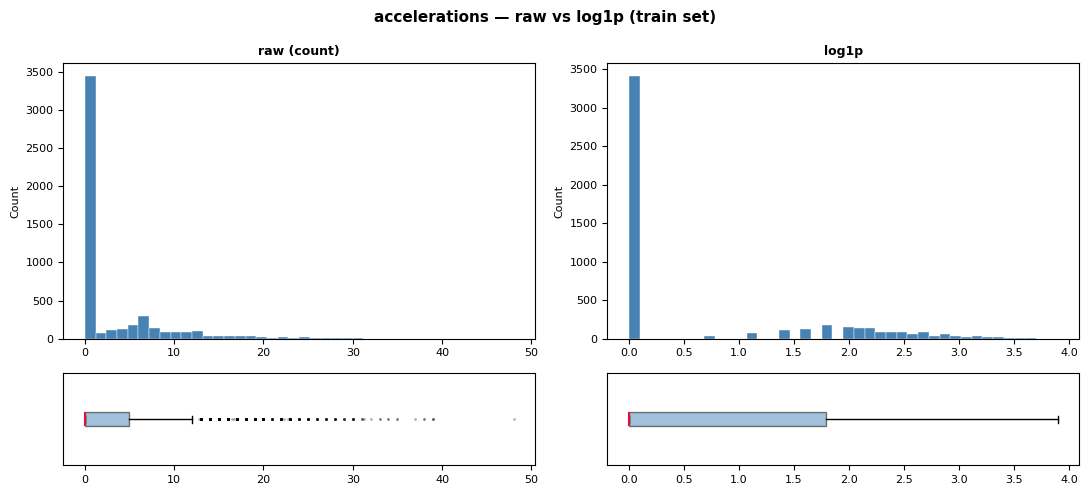

Zero days: 67.5%  |  median: 0.0  |  max: 48.0


In [3]:
raw_values = np.expm1(y_tr_np)
log_values = y_tr_np

fig, axes = plt.subplots(2, 2, figsize=(11, 5), gridspec_kw={"height_ratios":[3,1]})
fig.suptitle(f"{TARGET} — raw vs log1p (train set)", fontsize=11, fontweight="bold")
for col_idx, (data, label) in enumerate([(raw_values, "raw (count)"), (log_values, "log1p")]):
    ax_h, ax_b = axes[0, col_idx], axes[1, col_idx]
    ax_h.hist(data, bins=40, color="steelblue", edgecolor="white", linewidth=0.3)
    ax_h.set_title(label, fontsize=9, fontweight="bold")
    ax_h.set_ylabel("Count", fontsize=8); ax_h.tick_params(labelsize=8)
    ax_b.boxplot(data, vert=False, patch_artist=True,
                 boxprops=dict(facecolor="steelblue", alpha=0.5),
                 medianprops=dict(color="crimson", linewidth=1.5),
                 flierprops=dict(marker=".", markersize=2, alpha=0.3))
    ax_b.set_yticks([]); ax_b.tick_params(labelsize=8)
plt.tight_layout(); plt.show()
zero_pct = (raw_values == 0).mean() * 100
print(f"Zero days: {zero_pct:.1f}%  |  median: {np.median(raw_values):.1f}  |  max: {raw_values.max():.1f}")


## 4. Model Training

### Methodology

Both models are tuned with **RandomizedSearchCV** using:

- **10-fold KFold** (shuffled, `random_state=42`) on the training set
- **50 random hyperparameter combinations** sampled from wide continuous distributions
- **Scoring:** `neg_mean_squared_error` on the log1p-transformed target
- **`error_score=np.nan`** — bad combos (numerical instability) are skipped silently

Both search spaces use `loguniform` for scale-sensitive parameters (learning rate, regularisation) and `uniform` / `randint` for bounded parameters.

In [4]:
cv10 = KFold(n_splits=10, shuffle=True, random_state=42)

def _r2_original(estimator, X, y_log):
    """R\u00b2 on the original scale via expm1 back-transform."""
    pred   = np.clip(np.expm1(estimator.predict(X)), 0, None)
    actual = np.expm1(np.asarray(y_log))
    return r2_score(actual, pred)

def _run_search(estimator, space, n_iter=50):
    s = RandomizedSearchCV(
        estimator=estimator, param_distributions=space,
        n_iter=n_iter, cv=cv10, scoring="neg_mean_squared_error",
        n_jobs=-1, random_state=42, refit=True, error_score=np.nan,
    )
    s.fit(X_tr_np, y_tr_np)
    return s


### 4a. XGBoost

Gradient-boosted trees with histogram-based splits (`tree_method='hist'`). The search space covers **15 hyperparameters**:

| Group | Parameters |
|---|---|
| Tree structure | `n_estimators`, `max_depth`, `max_leaves`, `min_child_weight`, `gamma`, `max_delta_step`, `grow_policy`, `max_bin` |
| Subsampling | `subsample`, `colsample_bytree`, `colsample_bylevel`, `colsample_bynode` |
| Regularisation | `learning_rate`, `reg_alpha` (L1), `reg_lambda` (L2) |

In [5]:
xgb_space = {
    "n_estimators":      randint(200, 3000),   "max_depth":         randint(2, 16),
    "max_leaves":        randint(0, 1024),      "min_child_weight":  loguniform(0.1, 500),
    "gamma":             loguniform(1e-6, 100), "max_delta_step":    randint(0, 10),
    "grow_policy":       ["depthwise", "lossguide"],
    "max_bin":           randint(64, 1024),
    "subsample":         uniform(0.3, 0.7),     "colsample_bytree":  uniform(0.3, 0.7),
    "colsample_bylevel": uniform(0.3, 0.7),     "colsample_bynode":  uniform(0.3, 0.7),
    "learning_rate":     loguniform(1e-3, 5e-1),
    "reg_alpha":         loguniform(1e-8, 100), "reg_lambda":        loguniform(1e-8, 100),
}
print("Training XGBoost (50 iters, 10-fold CV)…")
xgb_search = _run_search(XGBRegressor(random_state=42, n_jobs=-1, verbosity=0, tree_method="hist"), xgb_space)
xgb_best   = xgb_search.best_estimator_
print(f"  Best CV RMSE (log1p): {np.sqrt(-xgb_search.best_score_):.4f}")
print(f"  Best params: {xgb_search.best_params_}")


Training XGBoost (50 iters, 10-fold CV)…
  Best CV RMSE (log1p): 0.3142
  Best params: {'colsample_bylevel': np.float64(0.5621780831931538), 'colsample_bynode': np.float64(0.9655000144869412), 'colsample_bytree': np.float64(0.8123957592679836), 'gamma': np.float64(0.06155564318973025), 'grow_policy': 'depthwise', 'learning_rate': np.float64(0.01596942308137678), 'max_bin': 278, 'max_delta_step': 7, 'max_depth': 6, 'max_leaves': 99, 'min_child_weight': np.float64(0.3376448065950811), 'n_estimators': 330, 'reg_alpha': np.float64(1.6063676259174453e-08), 'reg_lambda': np.float64(50.01479828856935), 'subsample': np.float64(0.8827098485602951)}


### 4b. Random Forest

Bagged ensemble of decision trees. Key parameters searched:

| Parameter | Meaning |
|---|---|
| `n_estimators` | Number of trees (100–2000) |
| `max_depth` | Tree depth (`None` = fully grown, or 3–29) |
| `max_features` | Fraction of features at each split (0.1–1.0) |
| `max_samples` | Row subsampling fraction with replacement (0.5–1.0) |
| `ccp_alpha` | Cost-complexity pruning strength |
| `min_impurity_decrease` | Minimum impurity improvement for a split |

In [6]:
rf_space = {
    "n_estimators":          randint(100, 2000),
    "max_depth":             [None] + list(range(3, 30)),
    "min_samples_split":     randint(2, 30),
    "min_samples_leaf":      randint(1, 20),
    "max_features":          uniform(0.1, 0.9),
    "max_samples":           uniform(0.5, 0.5),
    "min_impurity_decrease": loguniform(1e-8, 1e-1),
    "ccp_alpha":             loguniform(1e-8, 1e-1),
}
print("Training Random Forest (50 iters, 10-fold CV)…")
rf_search = _run_search(RandomForestRegressor(random_state=42, n_jobs=-1), rf_space)
rf_best   = rf_search.best_estimator_
print(f"  Best CV RMSE (log1p): {np.sqrt(-rf_search.best_score_):.4f}")
print(f"  Best params: {rf_search.best_params_}")


Training Random Forest (50 iters, 10-fold CV)…
  Best CV RMSE (log1p): 0.3122
  Best params: {'ccp_alpha': np.float64(0.0003418462686313858), 'max_depth': 26, 'max_features': np.float64(0.8362132893302437), 'max_samples': np.float64(0.9303652916281717), 'min_impurity_decrease': np.float64(1.1185744978598895e-08), 'min_samples_leaf': 8, 'min_samples_split': 28, 'n_estimators': 748}


## 5. Learning Curves

Learning curves reveal how **generalisation improves with more training data** and whether the model is overfitting or underfitting.

At each of **8 training-size fractions** (10 % → 100 %), the best-fit model is refit and evaluated using **5-fold CV**:

- **Train R²** — score on the training portion of each fold
- **Val R²** — score on the held-out validation fold

All scores are on the **original untransformed scale** via `expm1`. Shaded bands show ±1 standard deviation across folds.

> **Interpretation:** A large train–val gap = overfitting. Flat val R² as data grows = underfitting / data-limited.

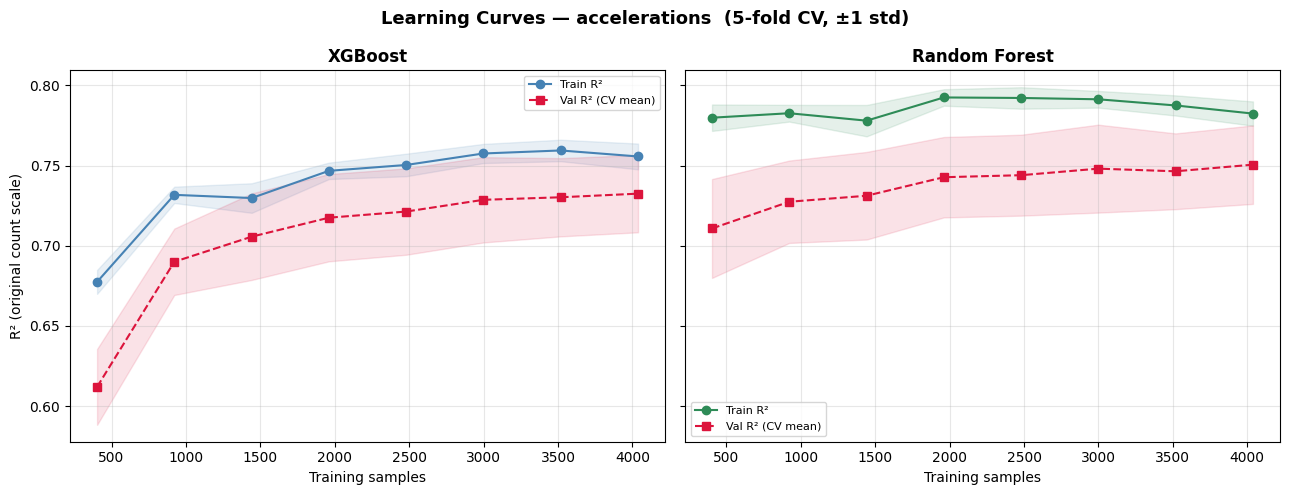

In [7]:
models = {"XGBoost": xgb_best, "Random Forest": rf_best}
colors = {"XGBoost": "steelblue", "Random Forest": "seagreen"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, (name, est) in zip(axes, models.items()):
    sizes, tr_sc, val_sc = learning_curve(
        clone(est), X_tr_np, y_tr_np,
        train_sizes=np.linspace(0.1, 1.0, 8),
        cv=KFold(n_splits=5, shuffle=True, random_state=42),
        scoring=_r2_original, n_jobs=-1,
    )
    tr_m, tr_s   = tr_sc.mean(axis=1),  tr_sc.std(axis=1)
    val_m, val_s = val_sc.mean(axis=1), val_sc.std(axis=1)
    c = colors[name]
    ax.plot(sizes, tr_m,  "o-",  color=c,        label="Train R²")
    ax.fill_between(sizes, tr_m-tr_s,  tr_m+tr_s,  alpha=0.12, color=c)
    ax.plot(sizes, val_m, "s--", color="crimson", label="Val R² (CV mean)")
    ax.fill_between(sizes, val_m-val_s, val_m+val_s, alpha=0.12, color="crimson")
    ax.set_title(name, fontweight="bold")
    ax.set_xlabel("Training samples"); ax.grid(True, alpha=0.3); ax.legend(fontsize=8)
axes[0].set_ylabel("R\u00b2 (original count scale)")
fig.suptitle(f"Learning Curves \u2014 {TARGET}  (5-fold CV, \u00b11 std)", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


## 6. Final Evaluation on Test Set

**The test set has never been seen by any preprocessing fit, CV fold, or hyperparameter selection step until this cell.**

`prepare_test()` applies the transforms fitted on train:
1. `day_of_week` → one-hot (`dow_0 … dow_6`)
2. `log1p(accelerations)`
3. Drop `total_distance` covariate
4. `scaler.transform(X[feature_cols])`

Metrics are reported in the **original scale** via `expm1` back-transform.

> `cv_rmse*` is on the log1p scale and is **not** directly comparable to RMSE/MAE above.

In [8]:
models = {"XGBoost": xgb_best, "Random Forest": rf_best}

test      = prepare_test(test_base, TARGET, scaler, feature_cols)
X_te      = test[feature_cols].to_numpy()
y_te      = test[TARGET].to_numpy()
actual_tr = np.expm1(y_tr_np)
actual_te = np.expm1(y_te)

_searches = {"XGBoost": xgb_search, "Random Forest": rf_search}
rows = []
for name, est in models.items():
    p_tr = np.clip(np.expm1(est.predict(X_tr_np)), 0, None)
    p_te = np.clip(np.expm1(est.predict(X_te)),    0, None)
    rows.append({
        "model":      name,
        "train_rmse": float(np.sqrt(mean_squared_error(actual_tr, p_tr))),
        "train_mae":  float(mean_absolute_error(actual_tr, p_tr)),
        "train_r2":   float(r2_score(actual_tr, p_tr)),
        "cv_rmse*":   float(np.sqrt(-_searches[name].best_score_)),
        "test_rmse":  float(np.sqrt(mean_squared_error(actual_te, p_te))),
        "test_mae":   float(mean_absolute_error(actual_te, p_te)),
        "test_r2":    float(r2_score(actual_te, p_te)),
    })

results = pd.DataFrame(rows).sort_values("test_rmse").reset_index(drop=True)
pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.width", 120)
print("\n" + "\u2500"*90)
print(f"Final results (* cv_rmse on log1p scale; train/test metrics in count)")
print("\u2500"*90)
print(results.to_string(index=False))



──────────────────────────────────────────────────────────────────────────────────────────
Final results (* cv_rmse on log1p scale; train/test metrics in count)
──────────────────────────────────────────────────────────────────────────────────────────
        model  train_rmse  train_mae  train_r2  cv_rmse*  test_rmse  test_mae  test_r2
Random Forest       2.689      1.107     0.779     0.312      2.691     1.096    0.757
      XGBoost       2.813      1.143     0.758     0.314      2.728     1.094    0.750


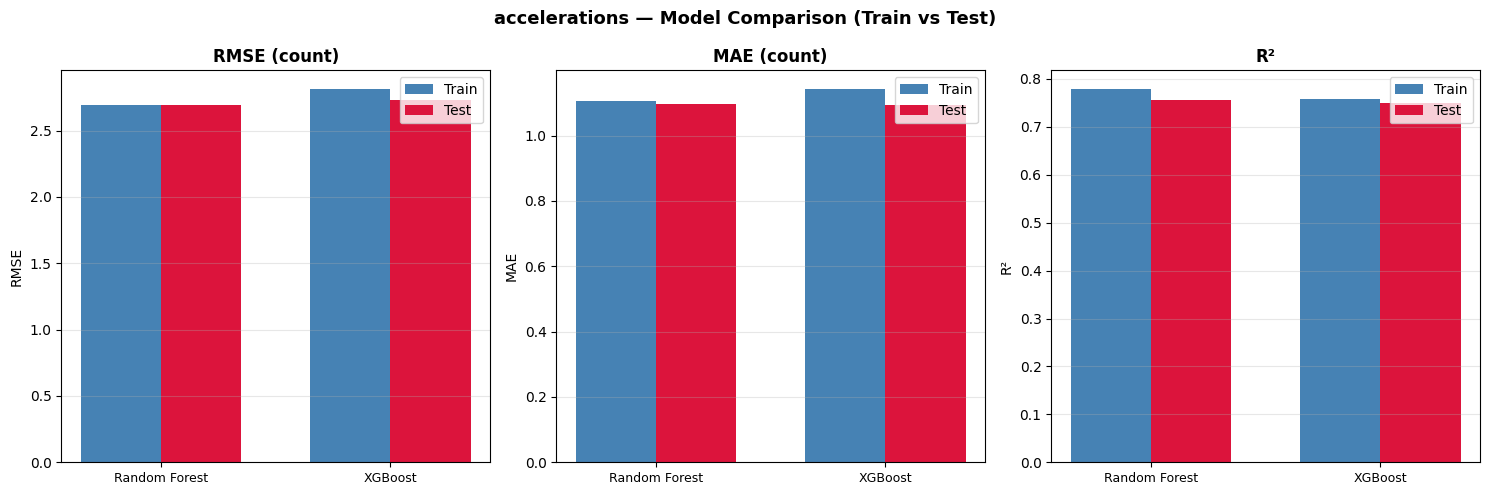

In [9]:
model_names = results["model"].tolist()
x, width    = np.arange(len(model_names)), 0.35

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f"{TARGET} \u2014 Model Comparison (Train vs Test)", fontsize=13, fontweight="bold")
for ax, (tr_col, te_col, title, ylabel) in zip(axes, [
    ("train_rmse","test_rmse", f"RMSE (count)", "RMSE"),
    ("train_mae", "test_mae",  f"MAE (count)",  "MAE"),
    ("train_r2",  "test_r2",   "R\u00b2",    "R\u00b2"),
]):
    ax.bar(x-width/2, results[tr_col], width, label="Train", color="steelblue")
    ax.bar(x+width/2, results[te_col], width, label="Test",  color="crimson")
    ax.set_title(title, fontweight="bold")
    ax.set_xticks(x); ax.set_xticklabels(model_names, fontsize=9)
    ax.set_ylabel(ylabel); ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()


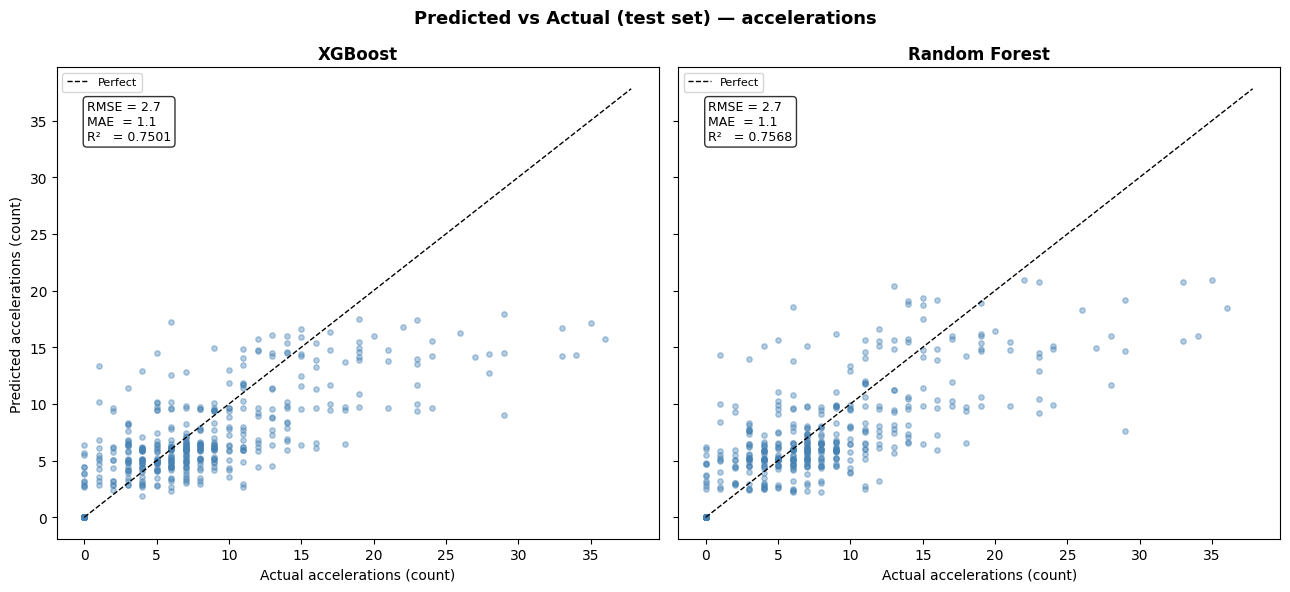

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharex=True, sharey=True)
for ax, (name, est) in zip(axes, models.items()):
    p_te = np.clip(np.expm1(est.predict(X_te)), 0, None)
    ax.scatter(actual_te, p_te, alpha=0.4, s=15, color="steelblue")
    lim = [0, max(actual_te.max(), p_te.max()) * 1.05]
    ax.plot(lim, lim, "k--", lw=1, label="Perfect")
    rmse = float(np.sqrt(mean_squared_error(actual_te, p_te)))
    mae  = float(mean_absolute_error(actual_te, p_te))
    r2   = float(r2_score(actual_te, p_te))
    ax.set_xlabel(f"Actual {TARGET} (count)")
    ax.set_title(name, fontweight="bold")
    ax.text(0.05, 0.93, f"RMSE = {rmse:.1f}\nMAE  = {mae:.1f}\nR\u00b2   = {r2:.4f}",
            transform=ax.transAxes, fontsize=9, va="top",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))
    ax.legend(fontsize=8)
axes[0].set_ylabel(f"Predicted {TARGET} (count)")
fig.suptitle(f"Predicted vs Actual (test set) \u2014 {TARGET}", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


## 7. SHAP Feature Analysis

SHAP (SHapley Additive exPlanations) provides model-agnostic, theoretically grounded feature attributions. `TreeExplainer` computes exact SHAP values efficiently for both tree-based models (XGBoost and Random Forest).

**Three visualisations, each comparing both models side by side:**

| Plot | What it shows |
|---|---|
| **Bar chart** | Mean \|SHAP\| per feature — global importance ranking |
| **Beeswarm** | Each dot = one test row; colour = feature value; x = SHAP value (direction) |
| **Waterfall** | Single-row breakdown for the highest-predicted sample |

> SHAP values are on the **log1p scale** (the scale the models were trained on). Positive SHAP = feature pushed the prediction **up**; negative = pushed it **down**.

In [11]:
# Compute SHAP values for BOTH models (TreeExplainer works for XGBoost and RF)
shap_data = {}
for name, est in models.items():
    explainer        = shap.TreeExplainer(est)
    shap_data[name]  = explainer(X_te)

for name, sv in shap_data.items():
    ma = pd.Series(np.abs(sv.values).mean(axis=0), index=feature_cols).sort_values(ascending=False)
    print(f"\nSHAP mean |SHAP| \u2014 {name}, target={TARGET}:")
    print(ma.round(4).to_string())



SHAP mean |SHAP| — XGBoost, target=accelerations:
n_periods          0.493
n_exercise_types   0.230
has_G              0.121
has_MATCH          0.058
height             0.034
has_TAC            0.029
weight             0.016
has_BP             0.015
age                0.006
dow_0              0.005
has_TEC            0.004
dow_5              0.002
dow_4              0.001
dow_6              0.001
dow_1              0.001
dow_3              0.001
dow_2              0.000

SHAP mean |SHAP| — Random Forest, target=accelerations:
n_periods          0.474
n_exercise_types   0.417
has_G              0.042
height             0.041
weight             0.014
has_MATCH          0.012
age                0.007
has_TEC            0.006
has_TAC            0.004
has_BP             0.002
dow_6              0.001
dow_3              0.001
dow_5              0.001
dow_2              0.001
dow_1              0.000
dow_4              0.000
dow_0              0.000


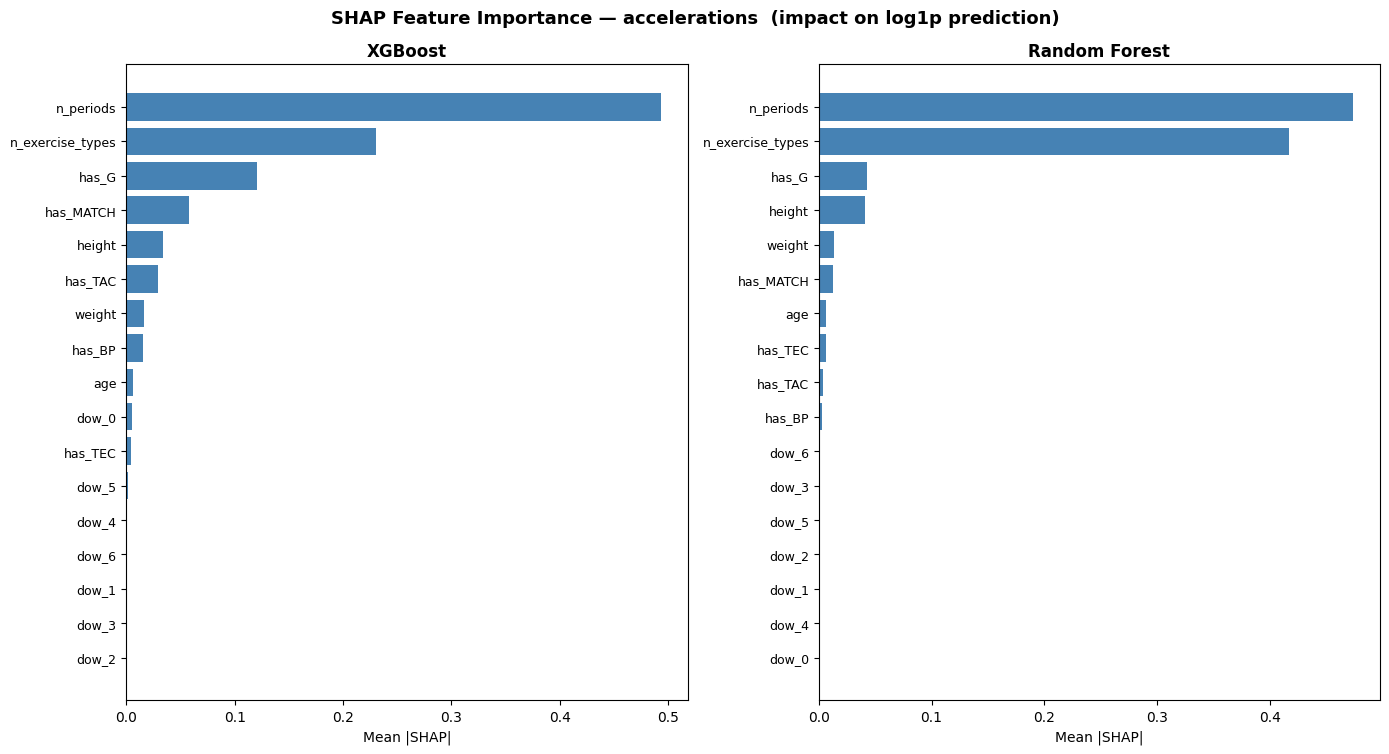

In [12]:
# Mean |SHAP| bar chart — both models side by side
fig, axes = plt.subplots(1, 2, figsize=(14, max(4, len(feature_cols) * 0.45)))
for ax, (name, sv) in zip(axes, shap_data.items()):
    ma = pd.Series(np.abs(sv.values).mean(axis=0), index=feature_cols).sort_values()
    ax.barh(range(len(ma)), ma.values, color="steelblue")
    ax.set_yticks(range(len(ma))); ax.set_yticklabels(ma.index, fontsize=9)
    ax.set_xlabel("Mean |SHAP|")
    ax.set_title(name, fontweight="bold")
fig.suptitle(f"SHAP Feature Importance \u2014 {TARGET}  (impact on log1p prediction)",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


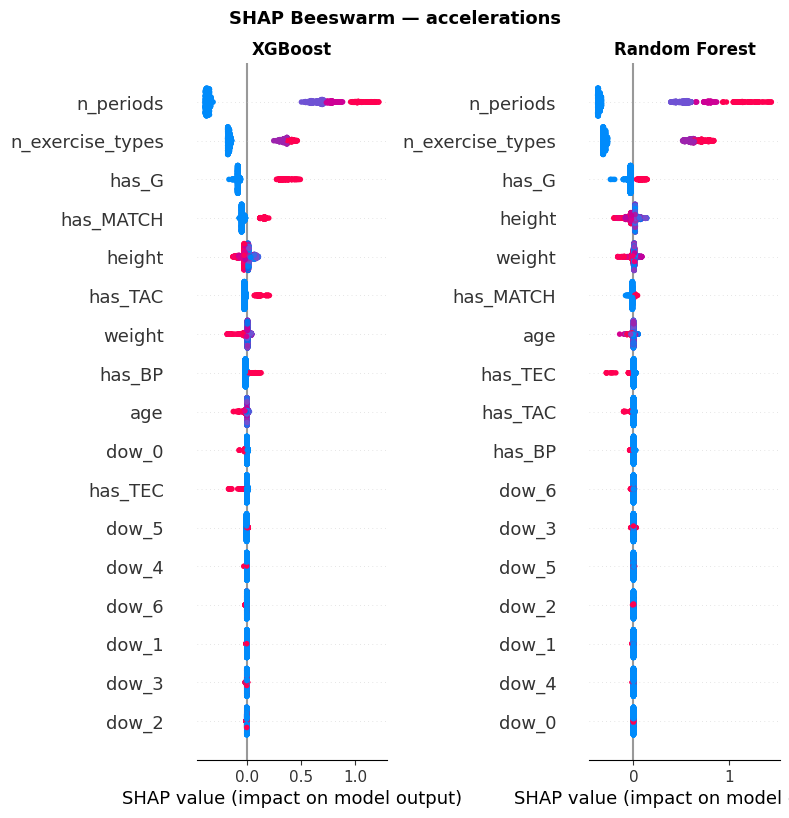

In [13]:
# Beeswarm — direction of effect, both models side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (name, sv) in zip(axes, shap_data.items()):
    plt.sca(ax)
    shap.summary_plot(sv.values, X_te, feature_names=feature_cols,
                      plot_type="dot", max_display=len(feature_cols),
                      show=False, color_bar=False)
    ax.set_title(name, fontweight="bold")
fig.suptitle(f"SHAP Beeswarm \u2014 {TARGET}", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


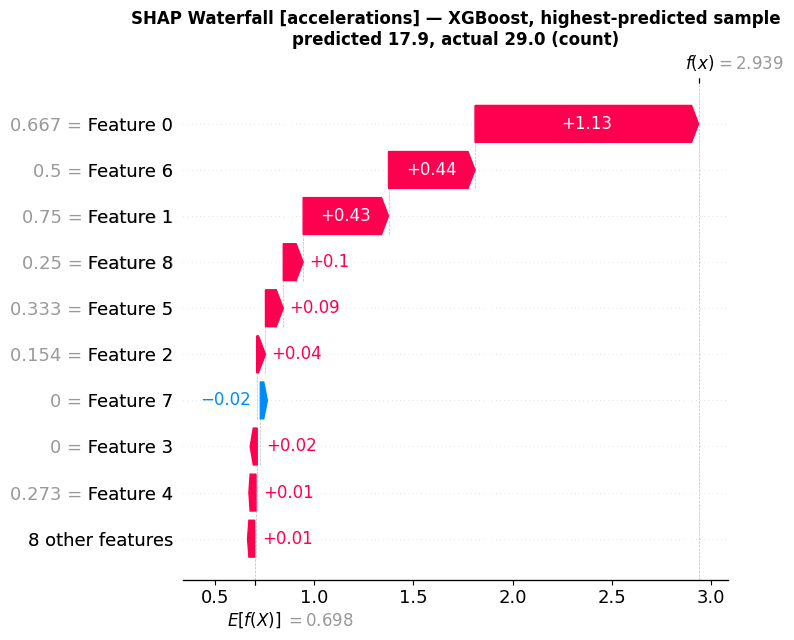

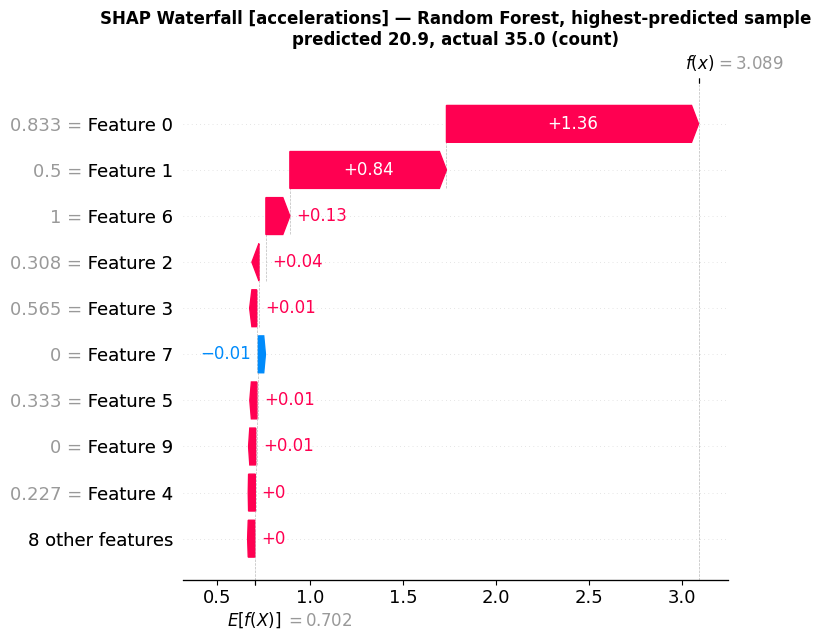

In [14]:
# Waterfall — highest-predicted test sample, for each model
for name, sv in shap_data.items():
    est     = models[name]
    preds   = np.clip(np.expm1(est.predict(X_te)), 0, None)
    top_idx = int(np.argmax(preds))
    shap.plots.waterfall(sv[top_idx], show=False)
    plt.title(f"SHAP Waterfall [{TARGET}] \u2014 {name}, highest-predicted sample\n"
              f"predicted {preds[top_idx]:.1f}, actual {actual_te[top_idx]:.1f} (count)",
              fontweight="bold")
    plt.tight_layout(); plt.show()
